In [2]:
# Import libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Load dataset
df = pd.read_csv("online_gaming_behavior_insights.csv")


In [3]:
# Show first rows
df.head()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [4]:
df.shape

(40034, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usag

In [8]:
df.describe()

,PlayerID,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
count,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000
mean,29016.500000,31.992531,12.024365,0.200854,9.471774,94.792252,49.655568,24.526477
std,11556.964675,10.043227,6.914638,0.400644,5.763667,49.011375,28.588379,14.430726
min,9000.000000,15.000000,0.000115,0.000000,0.000000,10.000000,1.000000,0.000000
25%,19008.250000,23.000000,6.067501,0.000000,4.000000,52.000000,25.000000,12.000000
50%,29016.500000,32.000000,12.008002,0.000000,9.000000,95.000000,49.000000,25.000000
75%,39024.750000,41.000000,17.963831,0.000000,14.000000,137.000000,74.000000,37.000000
max,49033.000000,49.000000,23.999592,1.000000,19.000000,179.000000,99.000000,49.000000


In [10]:
df.isnull().sum()

PlayerID                     0
Age                          0
Gender                       0
Location                     0
GameGenre                    0
PlayTimeHours                0
InGamePurchases              0
GameDifficulty               0
SessionsPerWeek              0
AvgSessionDurationMinutes    0
PlayerLevel                  0
AchievementsUnlocked         0
EngagementLevel              0
dtype: int64

In [11]:
df= df.drop('PlayerID',axis=1)

In [12]:
df["EngagementLevel"].value_counts()

EngagementLevel
Medium    19374
High      10336
Low       10324
Name: count, dtype: int64

C:\Users\HUWAEI\AppData\Local\Temp\ipykernel_11740\3406139017.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


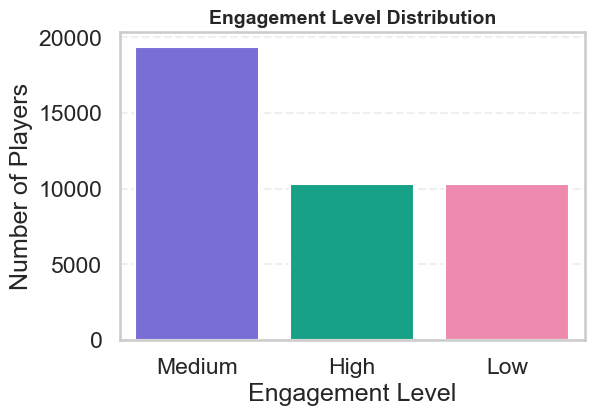

In [16]:
plt.figure(figsize=(6,4))


colors = ["#6C5CE7", "#00B894", "#FD79A8"]

sns.countplot(
    x='EngagementLevel',
    data=df,
    palette=colors
)

plt.title("Engagement Level Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Engagement Level")
plt.ylabel("Number of Players")

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

## يظهر أن معظم اللاعبين يقعون ضمن فئة التفاعل المتوسط بينما تتقارب نسبتا التفاعل العالي والمنخفض، مما يدل على توازن جيد في توزيع البيانات.


C:\Users\HUWAEI\AppData\Local\Temp\ipykernel_11740\463369970.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


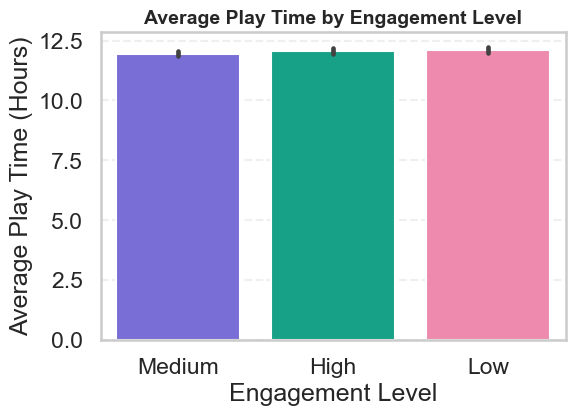

In [17]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='EngagementLevel',
    y='PlayTimeHours',
    data=df,
    palette=["#6C5CE7", "#00B894", "#FD79A8"]
)

plt.title("Average Play Time by Engagement Level", fontsize=14, fontweight='bold')
plt.xlabel("Engagement Level")
plt.ylabel("Average Play Time (Hours)")

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

## لا يوجد فرق واضح في متوسط عدد ساعات اللعب بين مستويات التفاعل المختلفة، مما يشير إلى أن وقت اللعب وحده ليس مؤشرًا كافيًا لتحديد مستوى تفاعل اللاعب

# ______________________________________________________________________________

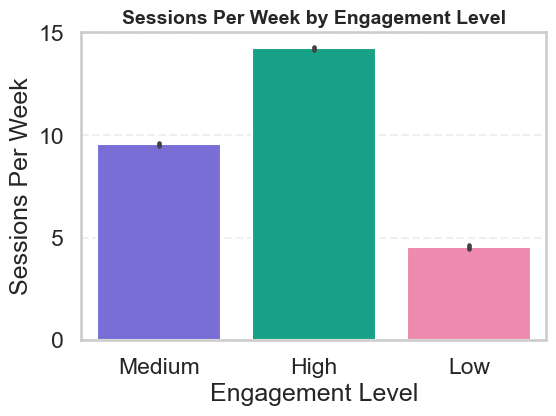

In [18]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='EngagementLevel',
    y='SessionsPerWeek',
    data=df,
    hue='EngagementLevel',
    palette=["#6C5CE7", "#00B894", "#FD79A8"],
    legend=False
)

plt.title("Sessions Per Week by Engagement Level", fontsize=14, fontweight='bold')
plt.xlabel("Engagement Level")
plt.ylabel("Sessions Per Week")

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [28]:
df.groupby("EngagementLevel").mean(numeric_only=True)

,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
EngagementLevel,,,,,,,
High,31.920085,12.069238,0.206463,14.254547,131.921827,50.823723,25.095975
Low,31.896939,12.104915,0.197307,4.530511,66.882119,46.101414,22.661565
Medium,32.082120,11.957503,0.199752,9.553267,89.856405,50.926293,25.216424


## يلاحظ أن اللاعبين ذوي التفاعل العالي  يميلون إلى عدد جلسات لعب أسبوعية أكبر، مما يدل على أن تكرار اللعب يرتبط بشكل إيجابي بمستوى التفاعل.

# ______________________________________________________________________________________

# أي نوع ألعاب فيه تفاعل أعلى؟

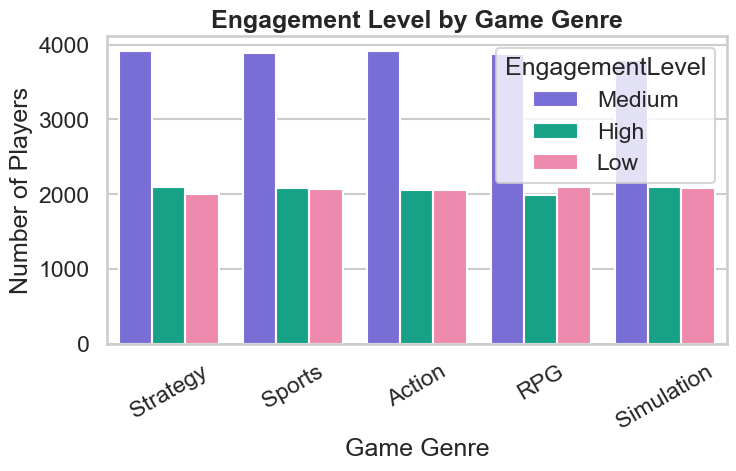

In [32]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="GameGenre", hue="EngagementLevel", palette=["#6C5CE7","#00B894","#FD79A8"])
plt.title("Engagement Level by Game Genre", fontweight="bold")
plt.xlabel("Game Genre")
plt.ylabel("Number of Players")
plt.xticks(rotation=30)
plt.show()

## لا يظهر اختلاف كبير في مستوى التفاعل بين أنواع الألعاب المختلفة، حيث تتقارب أعداد اللاعبين في جميع الفئات، مما يشير إلى أن نوع اللعبة ليس عاملًا رئيسيًا في تحديد مستوى التفاعل.

# __________________________________________________________________________________

# هل الشراء داخل اللعبة مرتبط بالتفاعل؟

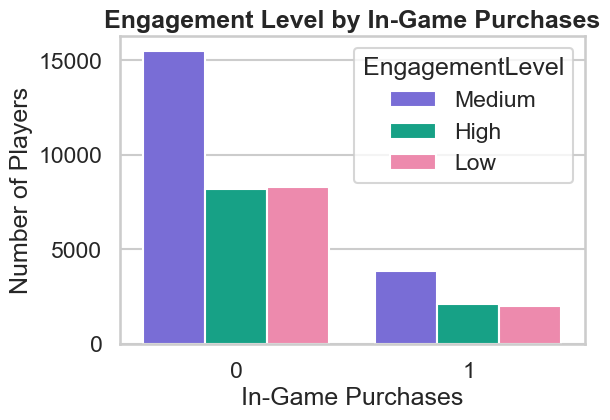

In [33]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="InGamePurchases", hue="EngagementLevel", palette=["#6C5CE7","#00B894","#FD79A8"])
plt.title("Engagement Level by In-Game Purchases", fontweight="bold")
plt.xlabel("In-Game Purchases")
plt.ylabel("Number of Players")
plt.show()

In [34]:
purchase_ratio = pd.crosstab(df["InGamePurchases"], df["EngagementLevel"], normalize="index")

purchase_ratio

EngagementLevel,High,Low,Medium
InGamePurchases,,,
0,0.256369,0.259025,0.484606
1,0.265390,0.253327,0.481283


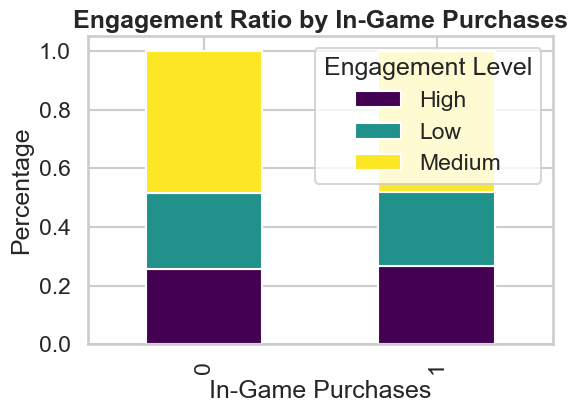

In [35]:
purchase_ratio.plot(kind="bar", stacked=True, figsize=(6,4), colormap="viridis")

plt.title("Engagement Ratio by In-Game Purchases", fontweight="bold")
plt.xlabel("In-Game Purchases")
plt.ylabel("Percentage")

plt.legend(title="Engagement Level")
plt.show()

In [19]:
from sklearn.preprocessing import LabelEncoder

# نسخة من الداتا
df_encoded = df.copy()

# الأعمدة النصية
categorical_cols = ['Gender', 'Location', 'GameGenre', 'GameDifficulty', 'EngagementLevel']

# تحويلها لأرقام
le = LabelEncoder()

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()

,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,43,1,2,4,16.271119,0,2,6,108,79,25,2
1,29,0,3,4,5.525961,0,2,5,144,11,10,2
2,22,0,3,3,8.223755,0,0,16,142,35,41,0
3,35,1,3,0,5.265351,1,0,9,85,57,47,2
4,33,1,1,0,15.531945,0,2,2,131,95,37,2


In [20]:
from sklearn.model_selection import train_test_split

# X = كل الأعمدة بدون الهدف
X = df_encoded.drop('EngagementLevel', axis=1)

# y = الهدف
y = df_encoded['EngagementLevel']

# تقسيم
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(32027, 11)
(8007, 11)


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# إنشاء المودل
model = RandomForestClassifier(random_state=42)


In [22]:
# تدريب
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [23]:
# التنبؤ
y_pred = model.predict(X_test)

In [24]:
# الدقة
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9099537904333708


## حقق النموذج دقة عالية بلغت 91%، مما يدل على قدرته الجيدة في التنبؤ بمستوى تفاعل اللاعبين بناءً على سلوكهم.

In [25]:
# تقرير مفصل
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.87      0.90      2035
           1       0.91      0.88      0.89      2093
           2       0.91      0.95      0.93      3879

    accuracy                           0.91      8007
   macro avg       0.91      0.90      0.91      8007
weighted avg       0.91      0.91      0.91      8007



In [26]:
# Feature Importance
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

feature_importance = feature_importance.sort_values(ascending=False)

feature_importance

SessionsPerWeek              0.427640
AvgSessionDurationMinutes    0.304045
PlayTimeHours                0.056802
PlayerLevel                  0.055513
AchievementsUnlocked         0.050700
Age                          0.041620
GameGenre                    0.020162
Location                     0.015813
GameDifficulty               0.012366
Gender                       0.008530
InGamePurchases              0.006810
dtype: float64

## يوضح التحليل أن عدد الجلسات الأسبوعية ومتوسط مدة الجلسة هما الأكثر تأثيرًا في تحديد مستوى تفاعل اللاعبين، بينما كان تأثير العوامل الأخرى مثل الجنس والمشتريات داخل اللعبة محدودًا.

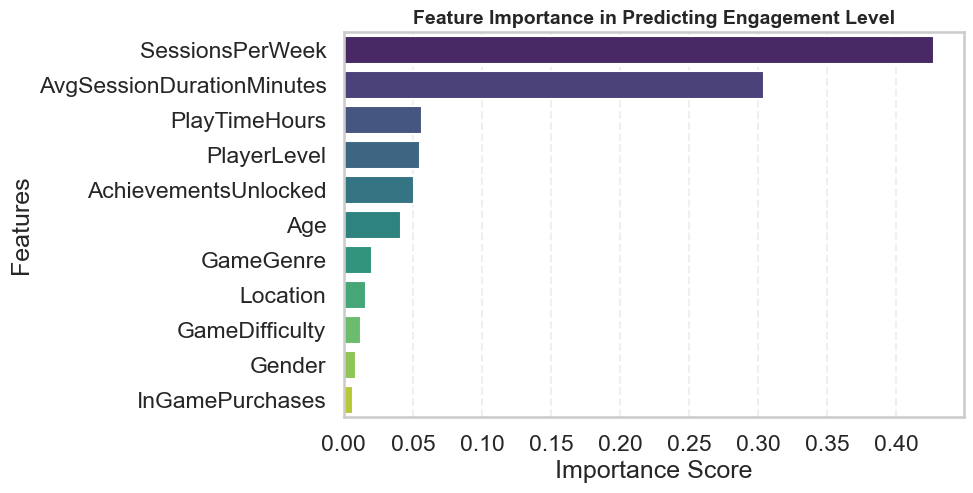

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=feature_importance.values,
    y=feature_importance.index,
    hue=feature_importance.index,
    palette="viridis",
    legend=False
)

plt.title("Feature Importance in Predicting Engagement Level", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.show()

## نلاحظ من الرسم أن العامل الأهم في تحديد مستوى التفاعل هو عدد الجلسات الأسبوعية، يليه متوسط مدة الجلسة، مما يدل على أن استمرارية اللعب أهم من إجمالي وقت اللعب.

In [36]:
df.to_csv("cleaned_gaming_data.csv", index=False)